In [1]:
 import pandas as pd
 import matplotlib.pyplot as plt
 import numpy as np
 import seaborn as sns


ModuleNotFoundError: No module named 'seaborn'

In [ ]:
pip install matplotlib

In [ ]:
pip install scikit-learn

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [ ]:
data = load_breast_cancer(as_frame=True)

In [ ]:
X = data.data
y = data.target

df = X # Assigning features to df to align with prior usage

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
rf=RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred=rf.predict(X_test)


In [ ]:
print("accuracy score:",accuracy_score(y_test,rf_pred))
print("\n Classification_report\n",classification_report(y_test,rf_pred))
print("\n Confusion_matrix\n",confusion_matrix(y_test,rf_pred))

accuracy score: 0.956140350877193

 Classification_report
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


 Confusion_matrix
 [[39  3]
 [ 2 70]]


In [ ]:
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)

In [ ]:
print("accuracy score:",accuracy_score(y_test,xgb_pred))
print("\n Classification_report\n",classification_report(y_test,xgb_pred))
print("\n Confusion_matrix\n",confusion_matrix(y_test,xgb_pred))

accuracy score: 0.956140350877193

 Classification_report
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


 Confusion_matrix
 [[38  4]
 [ 1 71]]


In [ ]:
lightgbm=LGBMClassifier()
lightgbm.fit(X_train,y_train)
lightgbm_pred=lightgbm.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000341 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [ ]:
print("accuracy score:",accuracy_score(y_test,lightgbm_pred))
print("\n Classification_report\n",classification_report(y_test,lightgbm_pred))
print("\n Confusion_matrix\n",confusion_matrix(y_test,lightgbm_pred))

accuracy score: 0.9649122807017544

 Classification_report
               precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


 Confusion_matrix
 [[39  3]
 [ 1 71]]


In [ ]:
comparision=pd.DataFrame({
    "model":[
        "RandomForestClassifier","XGBClassifier","LGBMClassifier"
    ],
    "accuracy_score":[
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred),
        accuracy_score(y_test,lightgbm_pred)
    ],
    "precision":[
        precision_score(y_test,rf_pred),
        precision_score(y_test,xgb_pred),
        precision_score(y_test,lightgbm_pred)
    ],
    "recall":[
        recall_score(y_test,rf_pred),
        recall_score(y_test,xgb_pred),
        recall_score(y_test,lightgbm_pred)
    ],
    "f1_score":[
        f1_score(y_test,rf_pred),
        f1_score(y_test,xgb_pred),
        f1_score(y_test,lightgbm_pred)
    ]
})

In [ ]:
comparision

,model,accuracy_score,precision,recall,f1_score
0,RandomForestClassifier,0.956140,0.958904,0.972222,0.965517
1,XGBClassifier,0.956140,0.946667,0.986111,0.965986
2,LGBMClassifier,0.964912,0.959459,0.986111,0.972603


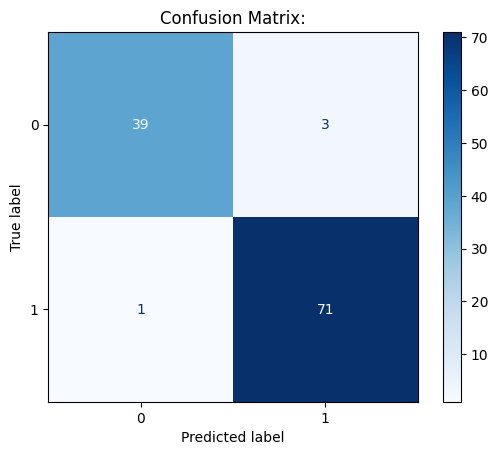

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lightgbm_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix:")
plt.show()

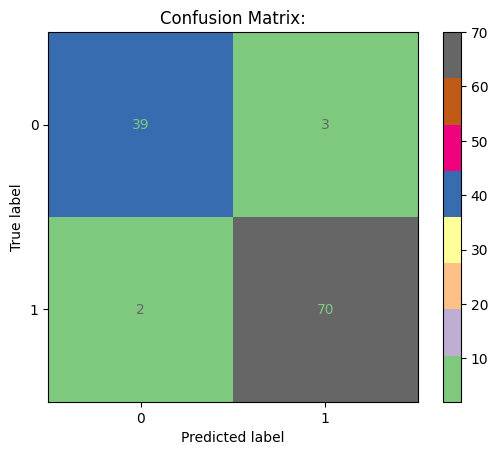

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay,roc

cm = confusion_matrix(y_test, rf_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Accent')
plt.title("Confusion Matrix:")
plt.show()

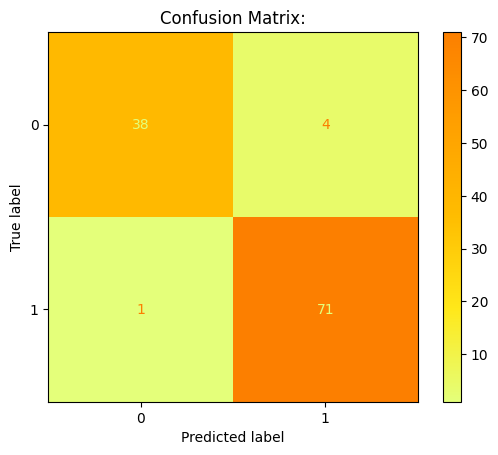

In [ ]:
cm = confusion_matrix(y_test,xgb_pred )
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Wistia')
plt.title("Confusion Matrix:")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

y_pred = xgb.predict(X_test)

y_prob=xgb.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test,y_prob)

print(roc_score)

0.9927248677248677


In [ ]:
y_pred = lightgbm.predict(X_test)

y_prob=lightgbm.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test,y_prob)

print(roc_score)

0.9897486772486772


In [ ]:
y_pred = rf.predict(X_test)

y_prob=rf.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test,y_prob)

print(roc_score)

0.9937169312169312


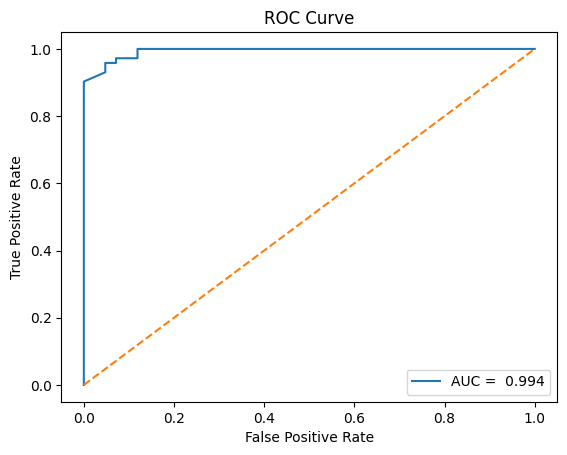

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr,tpr,thresholds=roc_curve(y_test,y_prob)
plt.plot(figsize=(8,6))
plt.plot(fpr,tpr,label=f"AUC =  {roc_score:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()